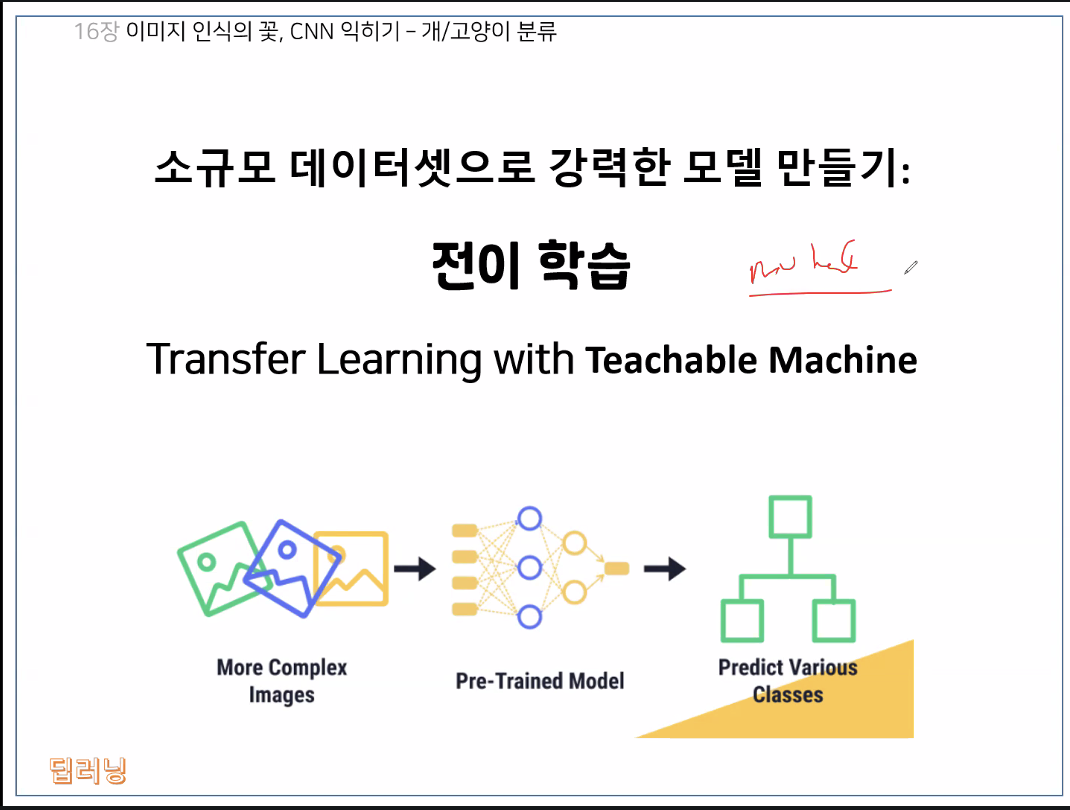

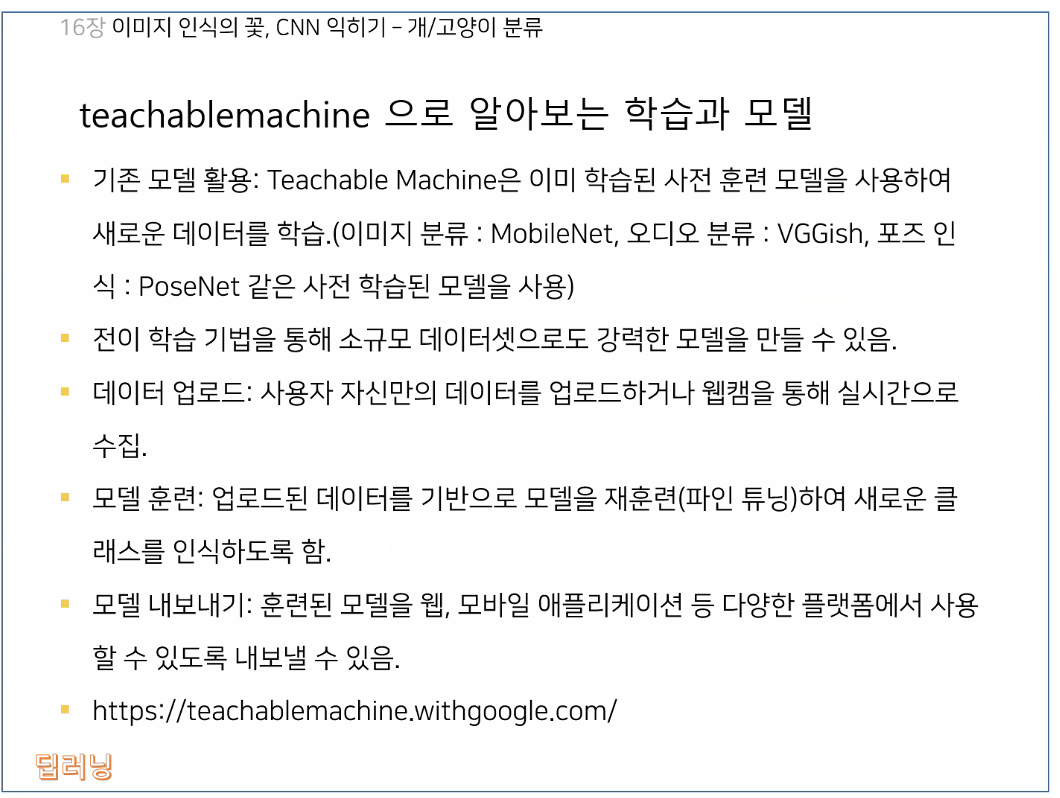

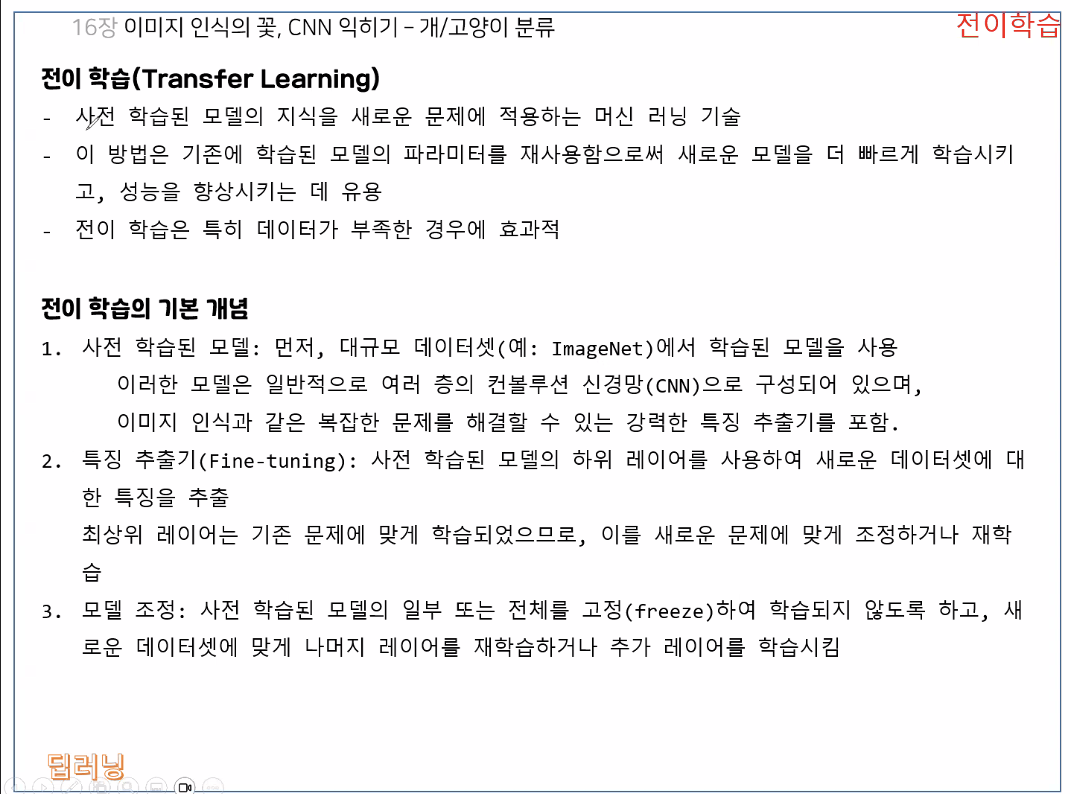

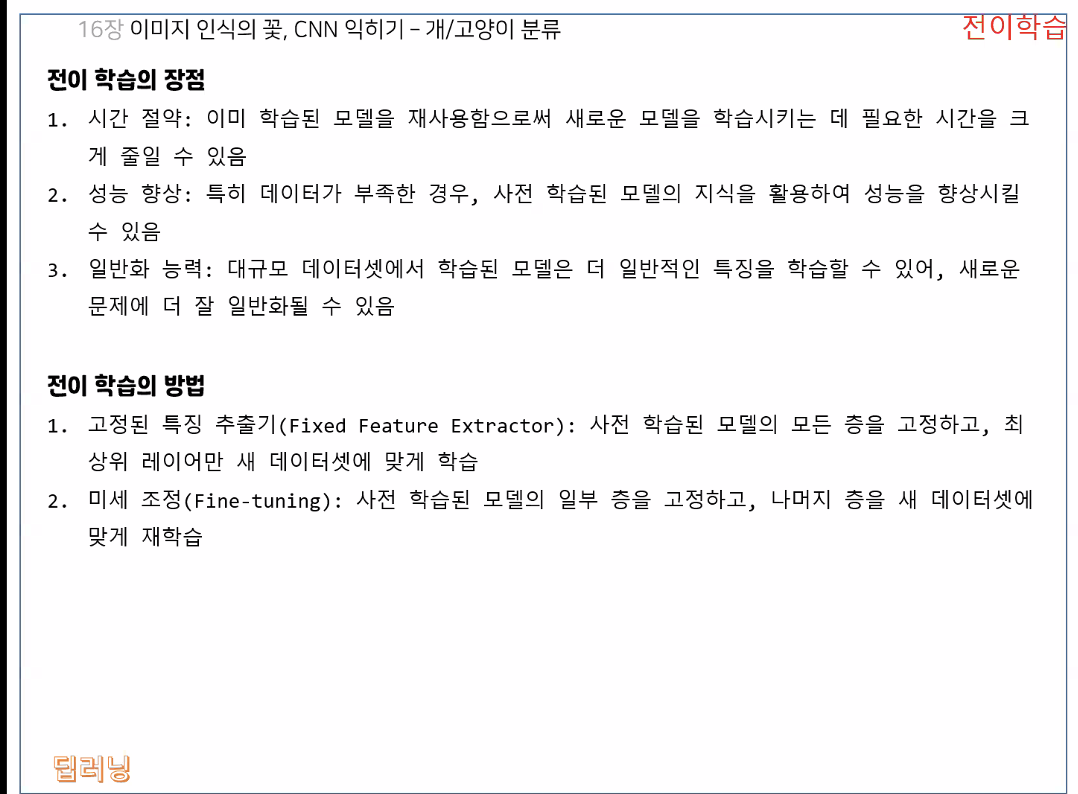

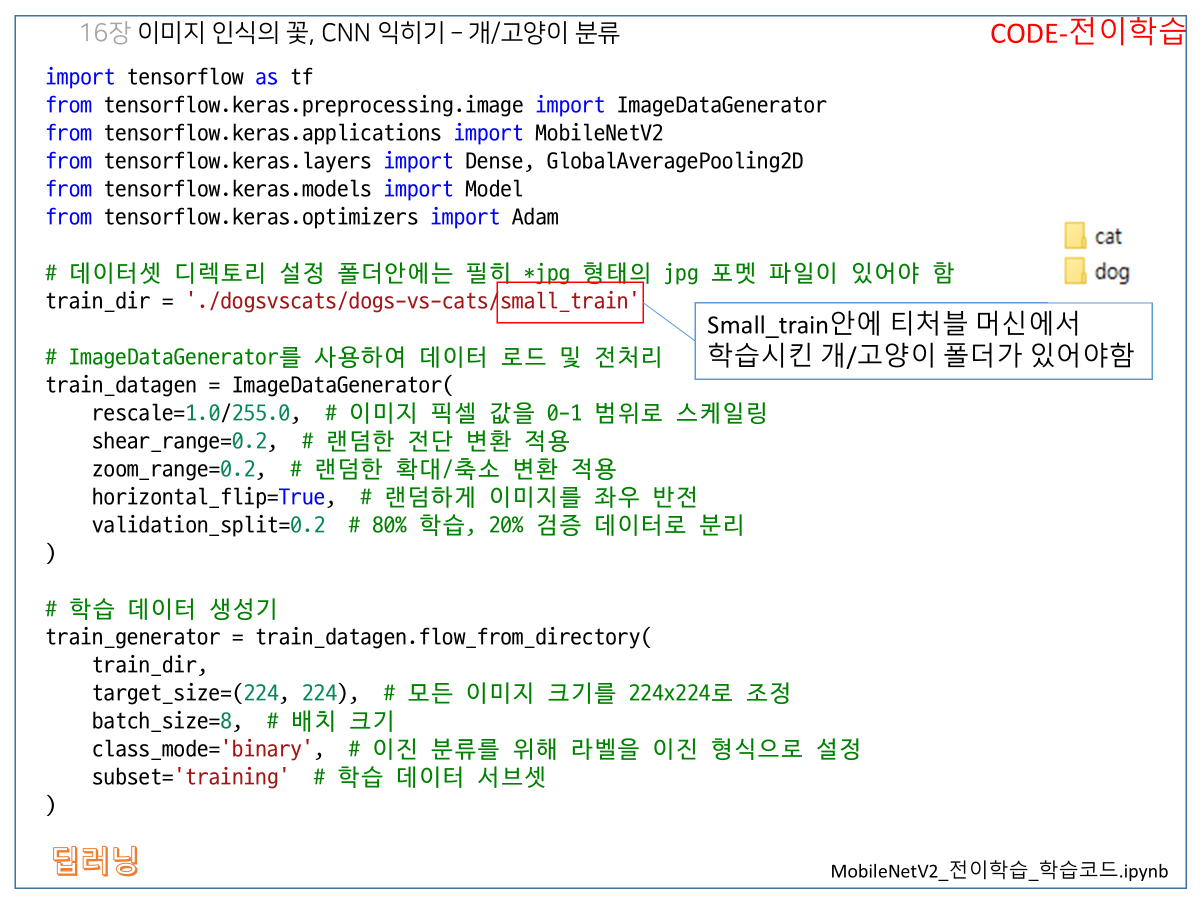

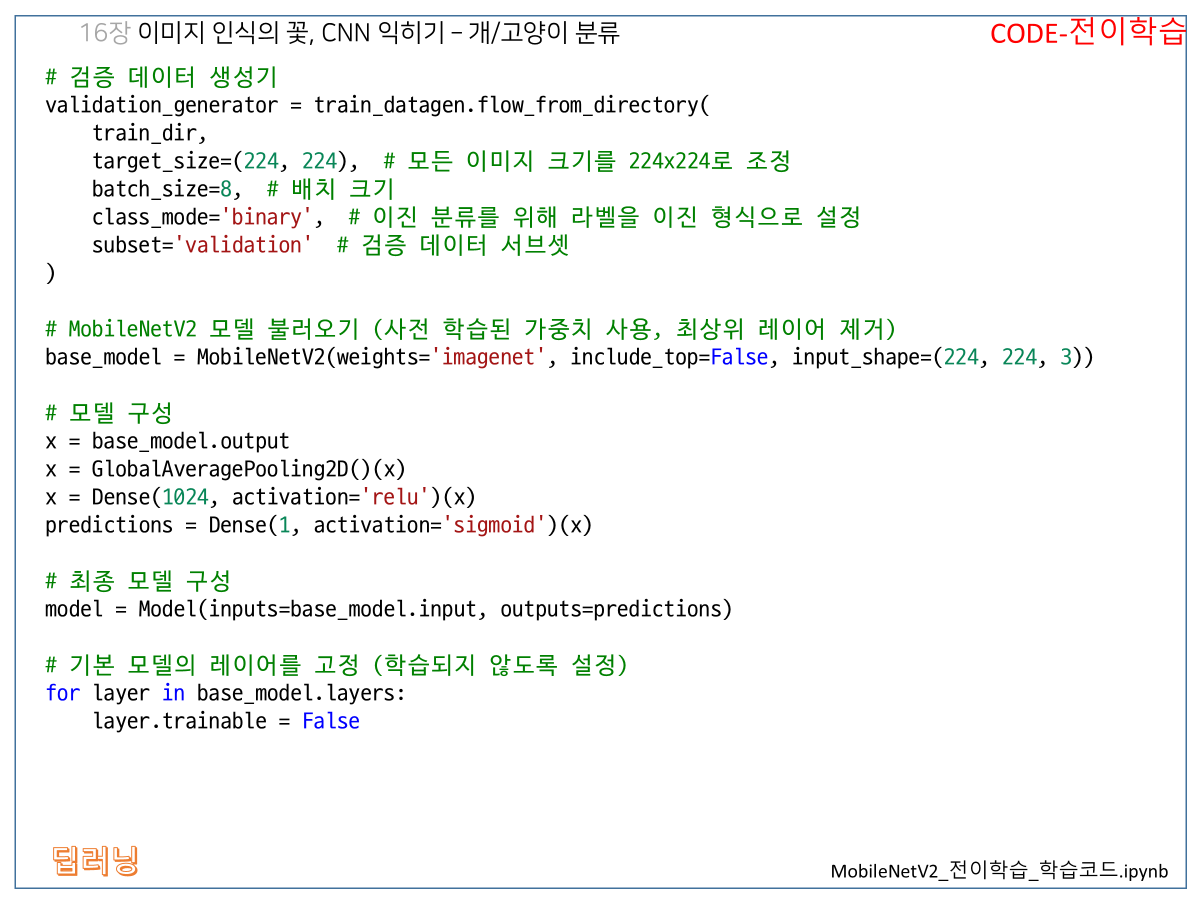

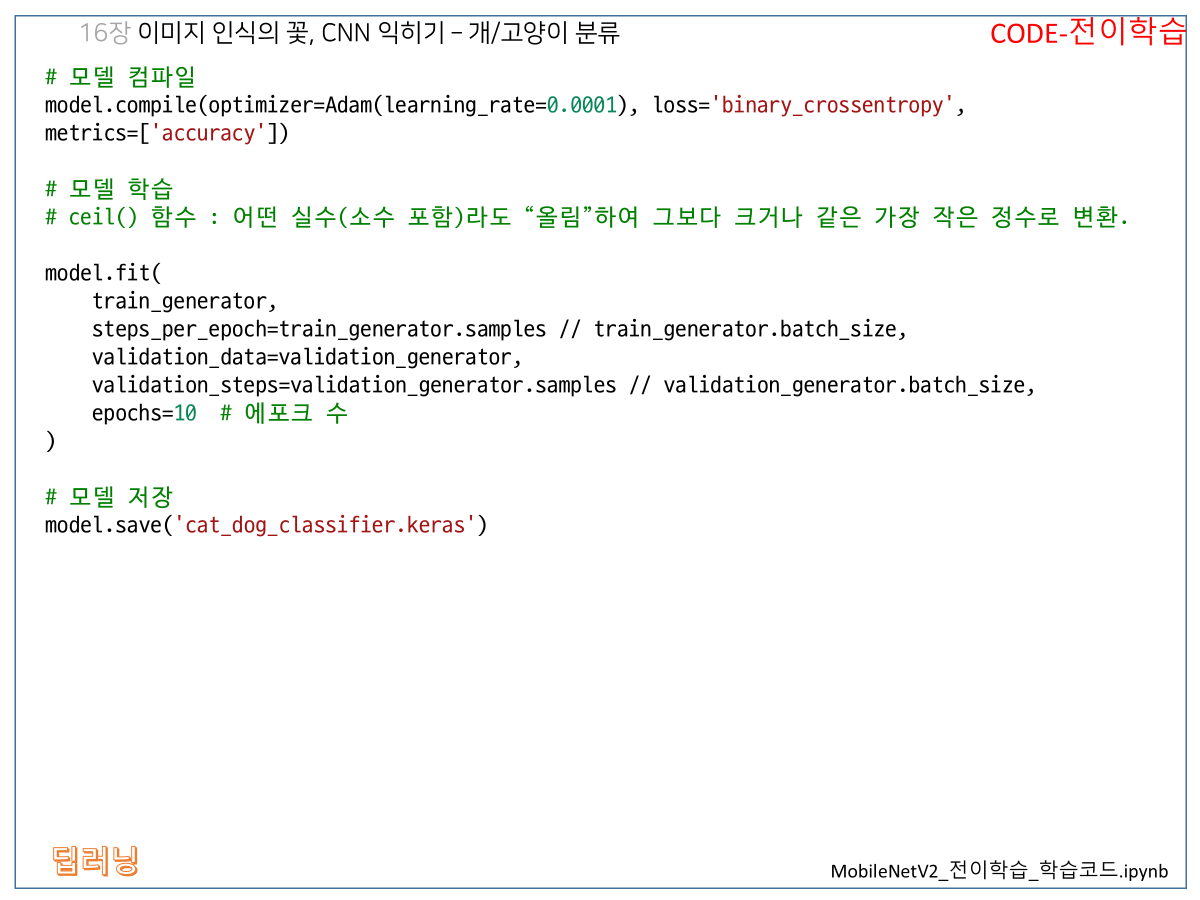

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# 데이터셋 디렉터리 설정
train_dir = './small_train'

# ImageDataGenerator를 사용하여 데이터 로드 및 전처리
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,     # 이미지 픽셀 값을 0~1 범위로 스케일링
    shear_range=0.2,         # 랜덤하게 전단 변환 적용
    zoom_range=0.2,          # 랜덤한 확대/축소 변환 적용
    horizontal_flip=True,    # 랜덤하게 이미지를 좌우 반전
    validation_split=0.2     # 80% 학습, 20% 검증 데이터로 분리
)

# 학습 데이터 생성기
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # 모든 이미지 크기를 224x224로 조정
    batch_size=8,            # 배치 크기
    class_mode='binary',     # 개/고양이 이진 분류
    subset='training'        # 학습 데이터 서브셋
)

# 검증 데이터 생성기
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # 모든 이미지 크기를 224x224로 조정
    batch_size=8,            # 배치 크기
    class_mode='binary',     # 개/고양이 이진 분류
    subset='validation'      # 검증 데이터 서브셋
)

# MobileNetV2 모델 불러오기
# imagenet으로 사전 학습된 가중치를 사용하고, 기존 분류기는 제외한다.
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 모델 구성
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

# 최종 모델 구성
model = Model(inputs=base_model.input, outputs=predictions)

# 기본 모델의 레이어를 고정하여 MobileNetV2 부분은 다시 학습되지 않게 한다.
for layer in base_model.layers:
    layer.trainable = False

# 모델 컴파일
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 모델 학습
# ceil() 함수: 어떤 실수라도 올림하여 그보다 크거나 같은 가장 작은 정수로 변환
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=10
)

# 모델 저장
model.save('cat_dog_classifier.keras')


Found 56 images belonging to 2 classes.
Found 14 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - accuracy: 0.8571 - loss: 0.4273 - val_accuracy: 1.0000 - val_loss: 0.1832
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 1.0000 - loss: 0.0895 - val_accuracy: 1.0000 - val_loss: 0.0840
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 1.0000 - loss: 0.0336 - val_accuracy: 1.0000 - val_loss: 0.0389
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 1.0000 - loss: 0.0135 - val_accuracy: 1.0000 - val_loss: 0.0160
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 1.0000 - loss: 0.0099 - val_accuracy: 1.0000 - val_loss: 0.0142
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 1.0000 - val_loss: 0.0168
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 1.0000 - val_loss: 0.

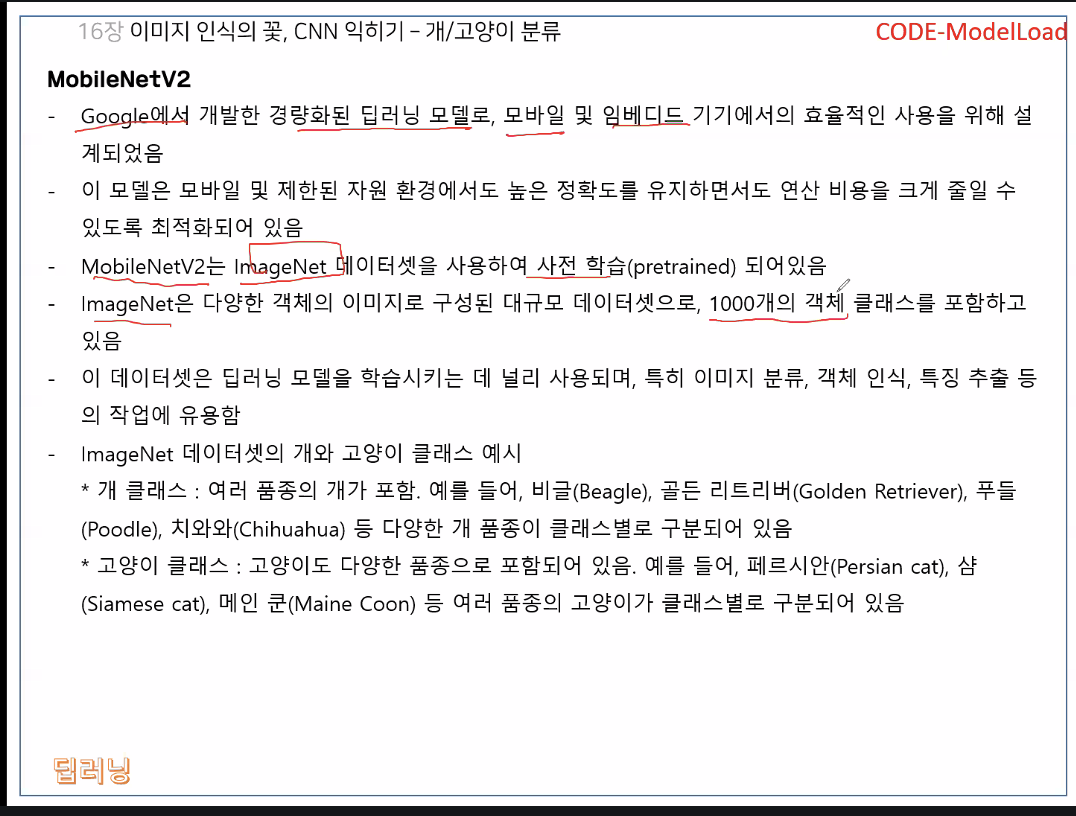

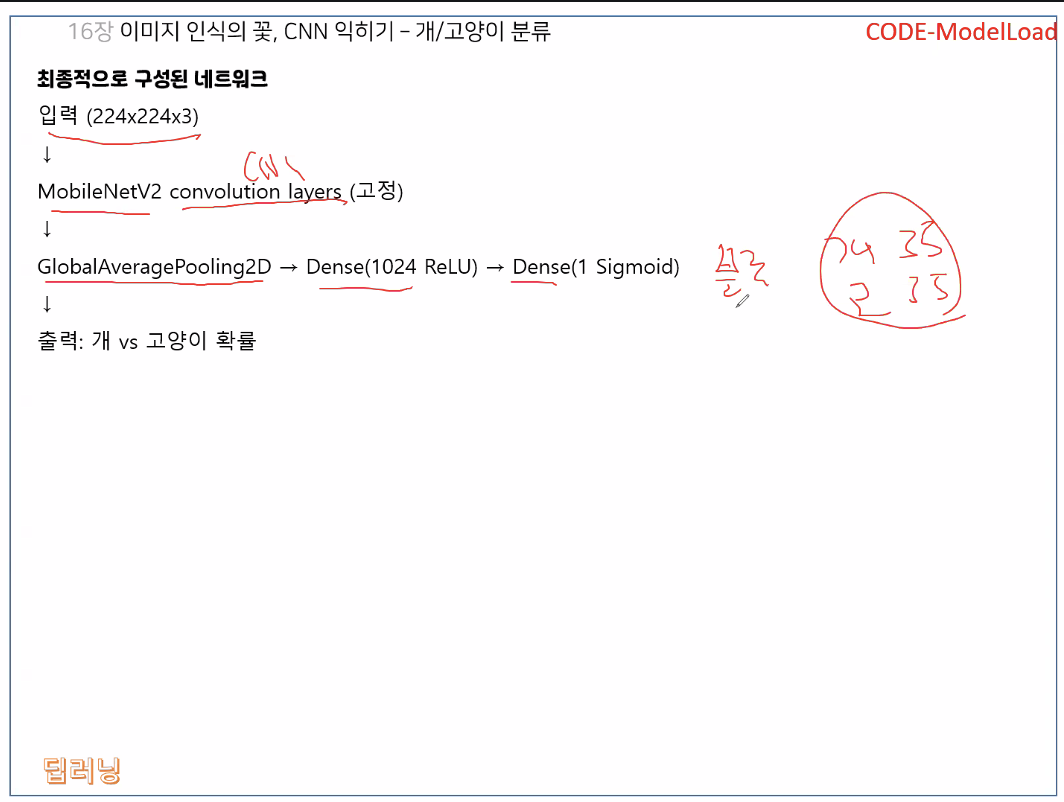

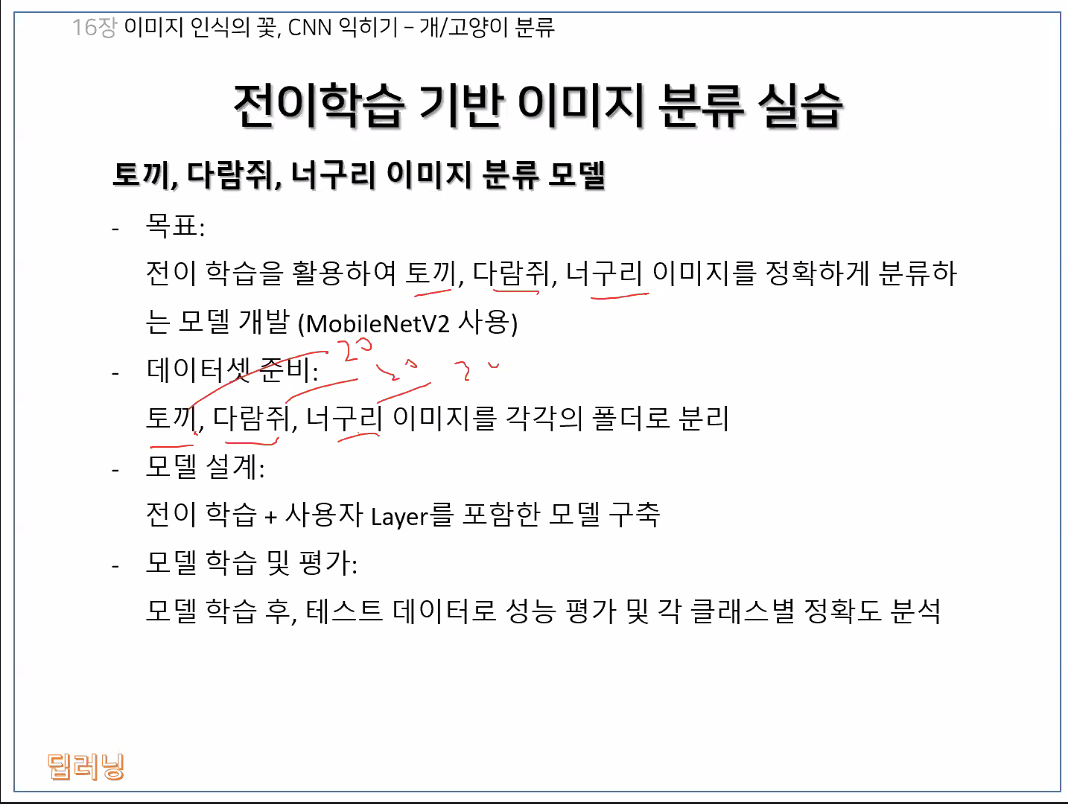

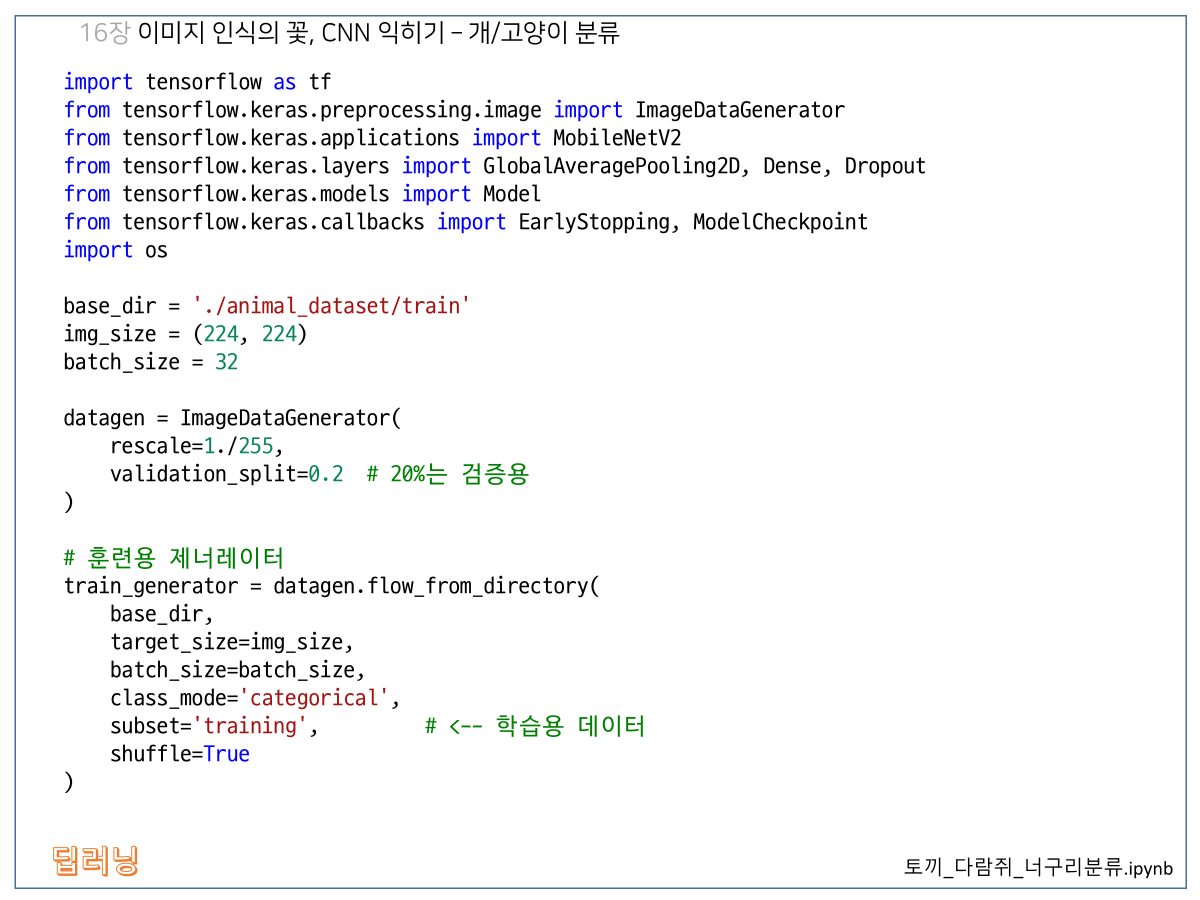

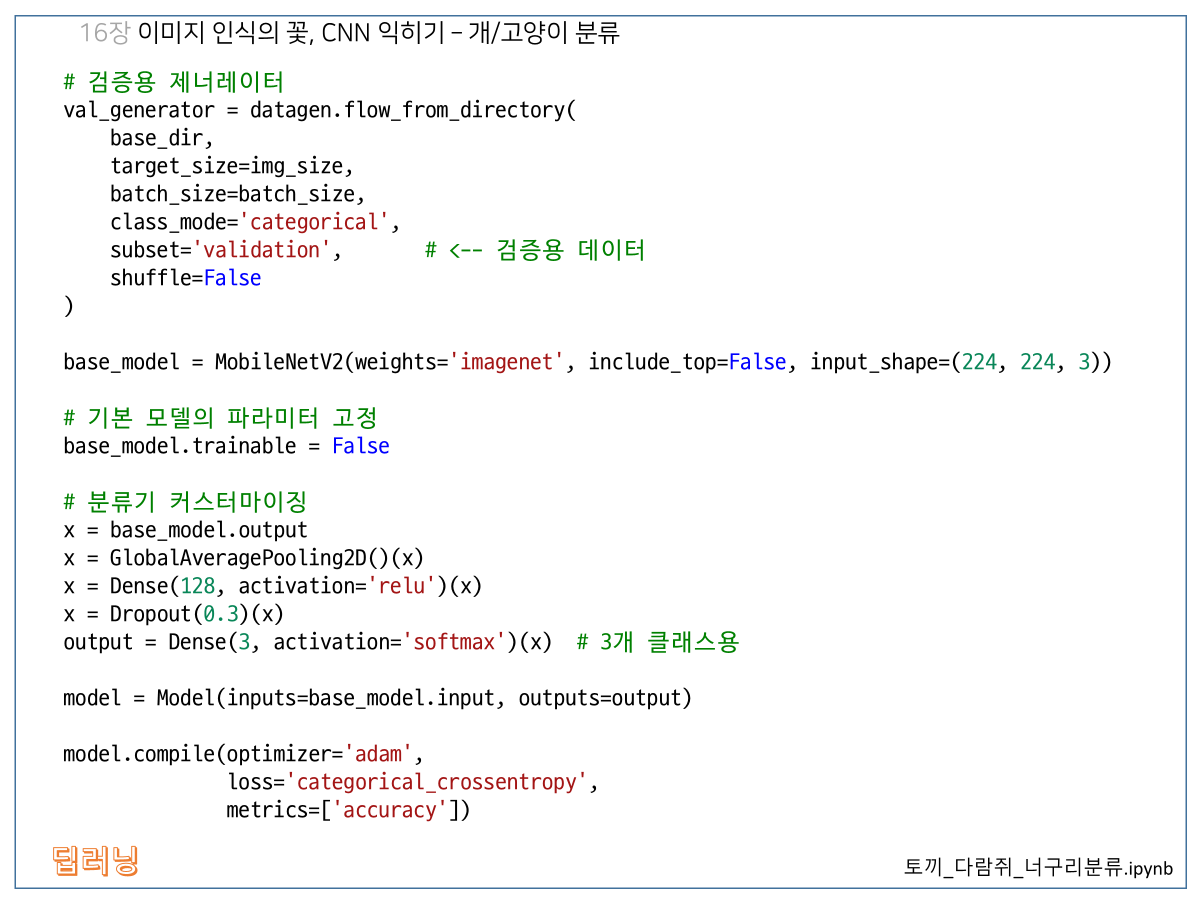

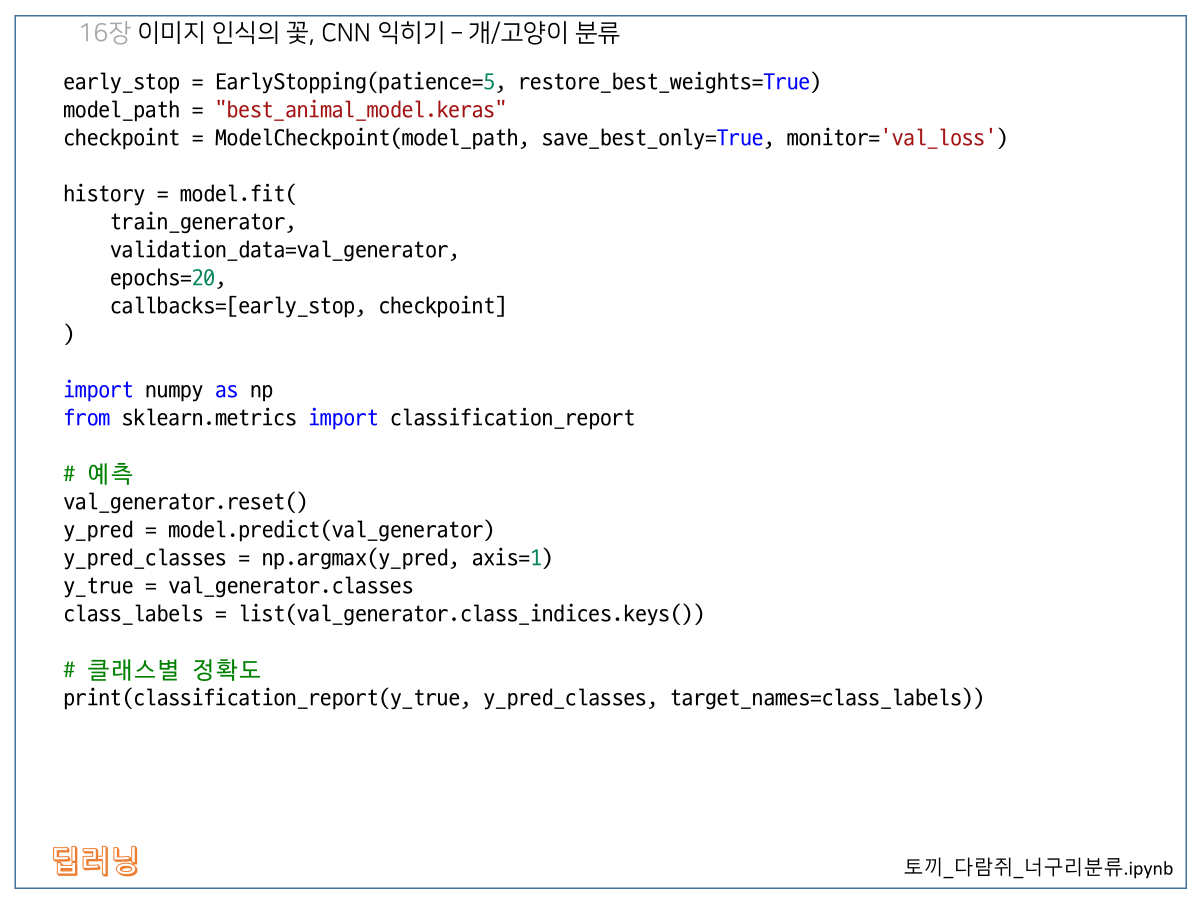